In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/telco_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [78]:
df.shape

(7043, 21)

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [80]:
df['TotalCharges'].unique()[:20]

<ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [81]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [82]:
# Convert to numeric; anything that can't convert (like ' ') becomes NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaNs we now have
df['TotalCharges'].isnull().sum()

np.int64(11)

In [83]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Confirm no more missing values
df['TotalCharges'].isnull().sum()

np.int64(0)

In [84]:
df.duplicated().sum()

np.int64(0)

In [85]:
df['customerID'].duplicated().sum()

np.int64(0)

In [86]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

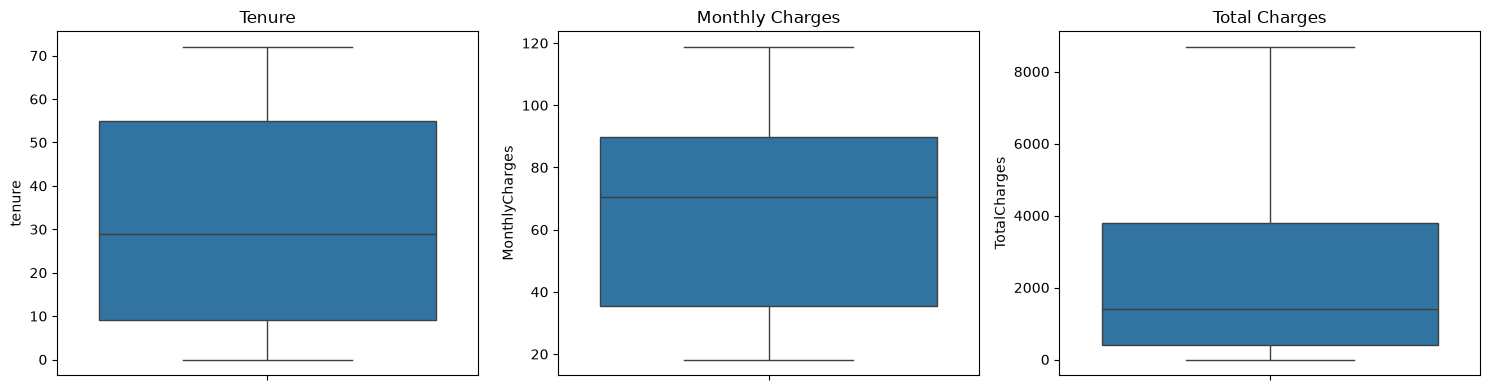

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df['tenure'], ax=axes[0])
axes[0].set_title('Tenure')

sns.boxplot(y=df['MonthlyCharges'], ax=axes[1])
axes[1].set_title('Monthly Charges')

sns.boxplot(y=df['TotalCharges'], ax=axes[2])
axes[2].set_title('Total Charges')

plt.tight_layout()
plt.show()

In [88]:
def count_outliers_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower) | (df[column] > upper)]
    print(f"{column}: {len(outliers)} outliers (bounds: {lower:.2f} to {upper:.2f})")

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    count_outliers_iqr(col)

tenure: 0 outliers (bounds: -60.00 to 124.00)
MonthlyCharges: 0 outliers (bounds: -46.02 to 171.38)
TotalCharges: 0 outliers (bounds: -4683.52 to 8868.67)


In [89]:
#cleaning done

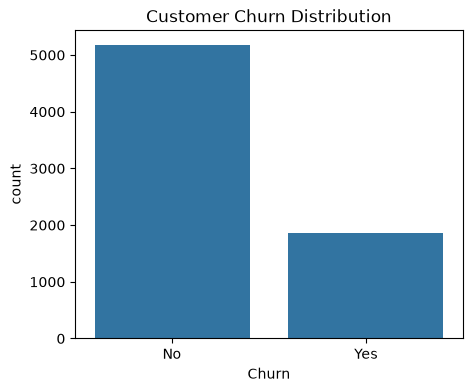

In [90]:
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df)
plt.title('Customer Churn Distribution')
plt.show()

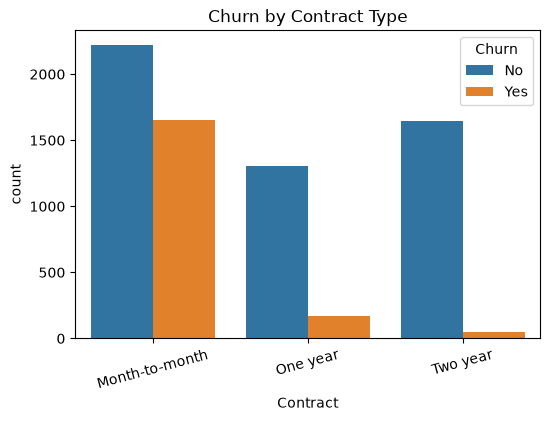

In [91]:
plt.figure(figsize=(6,4))
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xticks(rotation=15)
plt.show()

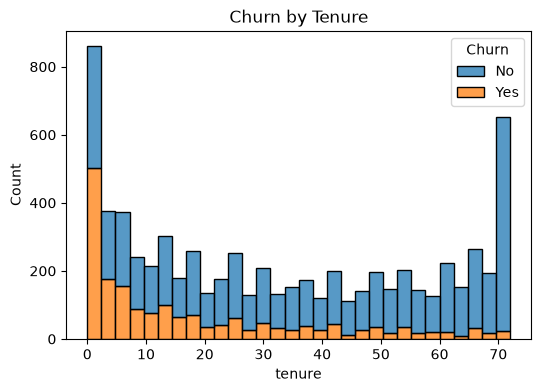

In [92]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Tenure')
plt.show()

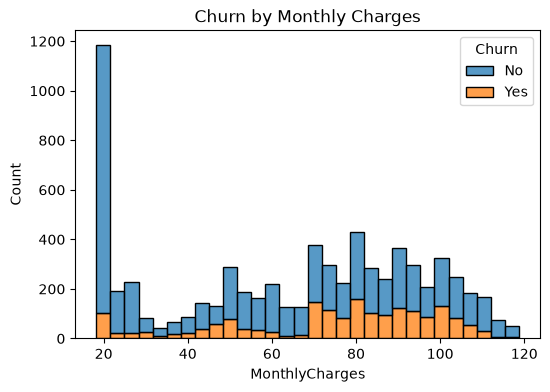

In [93]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', multiple='stack', bins=30)
plt.title('Churn by Monthly Charges')
plt.show()

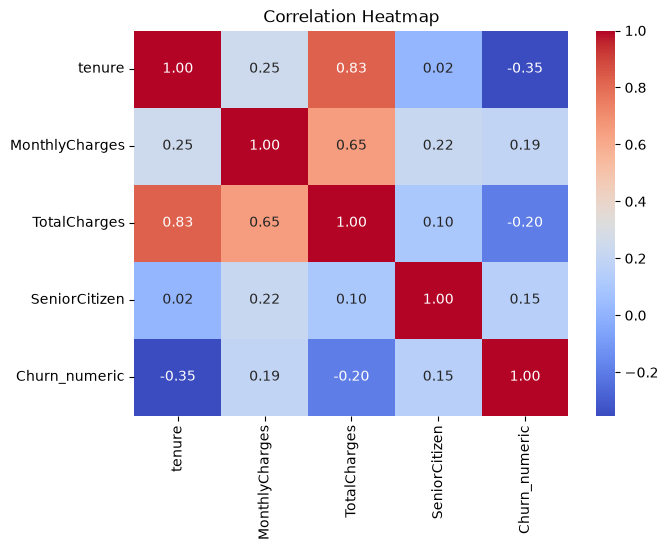

In [94]:
# Convert Churn to 0/1 temporarily just for correlation purposes
df_corr = df.copy()
df_corr['Churn_numeric'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_numeric']

plt.figure(figsize=(7,5))
sns.heatmap(df_corr[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [95]:
#  EDA Key Insights

# - **Class imbalance**: ~74% of customers stayed, ~26% churned — accuracy alone will be a misleading metric later.
# - **Contract type is a major churn driver**: month-to-month customers churn far more than annual contract holders.
# - **Tenure matters**: churn is concentrated heavily among newer customers (low tenure).
# - **Pricing sensitivity**: customers with mid-to-high MonthlyCharges churn more, likely fiber/premium plan subscribers.
# - **Data quality**: 11 rows had blank TotalCharges (new customers with 0 tenure) — corrected to 0. No duplicates, no meaningful outliers.
# - **Feature redundancy risk**: tenure and TotalCharges are strongly correlated — worth simplifying in feature engineering.

In [96]:
df['OnlineSecurity'].unique()

<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

In [97]:
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
                 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Count how many of these equal exactly 'Yes' for each customer
df['ServiceCount'] = (df[service_cols] == 'Yes').sum(axis=1)

df['ServiceCount'].describe()

count    7043.000000
mean        3.362914
std         2.062031
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: ServiceCount, dtype: float64

In [98]:
df['ServiceCount'].value_counts().sort_index()

ServiceCount
0      80
1    1701
2    1188
3     965
4     922
5     908
6     676
7     395
8     208
Name: count, dtype: int64

In [99]:
rfm = df[['customerID', 'tenure', 'ServiceCount', 'MonthlyCharges']].copy()
rfm.columns = ['customerID', 'Recency', 'Frequency', 'Monetary']
rfm.head()

,customerID,Recency,Frequency,Monetary
0,7590-VHVEG,1,1,29.85
1,5575-GNVDE,34,3,56.95
2,3668-QPYBK,2,3,53.85
3,7795-CFOCW,45,3,42.30
4,9237-HQITU,2,1,70.70


In [100]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

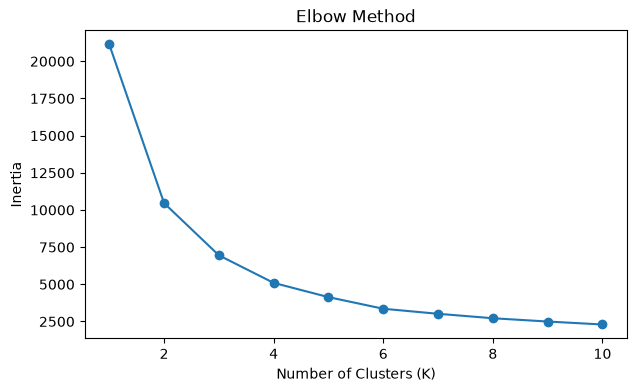

In [101]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [102]:
from sklearn.metrics import silhouette_score

for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}: Silhouette Score = {score:.3f}")

K=2: Silhouette Score = 0.426
K=3: Silhouette Score = 0.405
K=4: Silhouette Score = 0.421
K=5: Silhouette Score = 0.383
K=6: Silhouette Score = 0.395
K=7: Silhouette Score = 0.382


In [103]:
optimal_k = 4  # replace with what your elbow + silhouette actually show

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,10.272319,1.259473,29.889017
1,56.779384,5.769123,92.095756
2,14.787473,3.218575,77.597365
3,54.555015,1.853944,31.634080


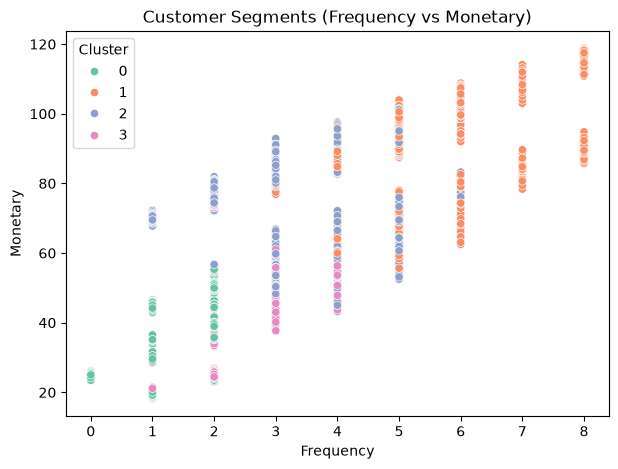

In [104]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2')
plt.title('Customer Segments (Frequency vs Monetary)')
plt.show()

In [105]:
plt.savefig('../images/customer_segments.png', dpi=150, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [106]:
df_model = df.drop(columns=['customerID'])

# Merge our RFM cluster back in as a feature (optional but strong — ties both halves of project together)
df_model = df_model.merge(rfm[['customerID', 'Cluster']], left_index=True, right_index=False, how='left') if False else df_model
# (simpler: just re-attach using index alignment since row order matches)
df_model['Cluster'] = rfm['Cluster'].values

# Encode target
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

df_model.shape

C:\Users\tanma\AppData\Local\Temp\ipykernel_28636\631203204.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include='object').columns.tolist()


(7043, 33)

In [107]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [108]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)

g:\projects\churn\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

--- Logistic Regression ---
Accuracy:  0.738
Precision: 0.504
Recall:    0.791
F1 Score:  0.616
ROC-AUC:   0.842



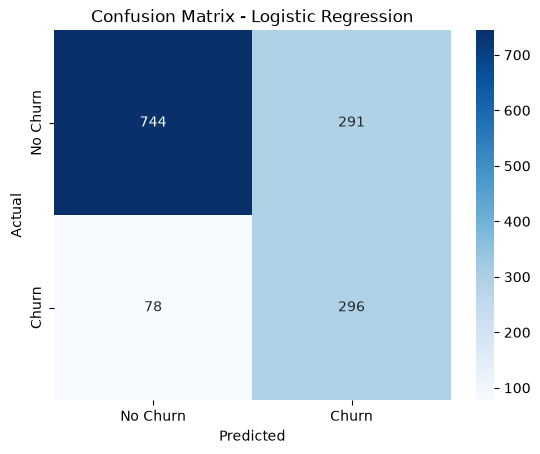

--- Random Forest ---
Accuracy:  0.772
Precision: 0.562
Recall:    0.642
F1 Score:  0.599
ROC-AUC:   0.825



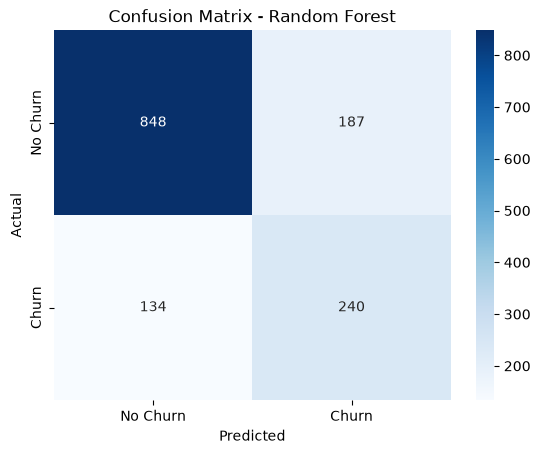

In [109]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                               f1_score, confusion_matrix, roc_auc_score, classification_report)

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.3f}")
    print()
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

evaluate_model(log_reg, X_test, y_test, "Logistic Regression")
evaluate_model(rf, X_test, y_test, "Random Forest")

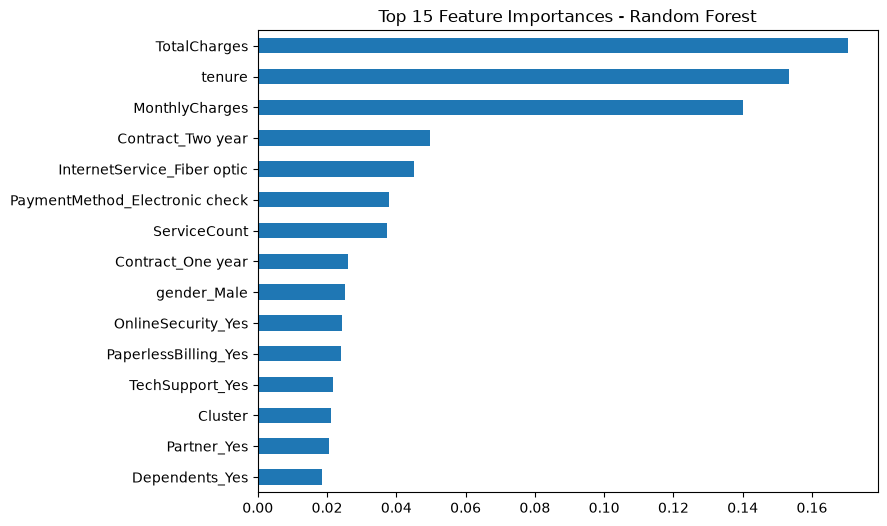

In [110]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind='barh')
plt.title('Top 15 Feature Importances - Random Forest')
plt.gca().invert_yaxis()
plt.show()

In [111]:
import joblib

joblib.dump(rf, '../models/churn_rf_model.pkl')
joblib.dump(log_reg, '../models/churn_logreg_model.pkl')
joblib.dump(scaler, '../models/rfm_scaler.pkl')
joblib.dump(kmeans, '../models/kmeans_model.pkl')
joblib.dump(X.columns.tolist(), '../models/model_columns.pkl')  # needed to align dashboard input columns later

['../models/model_columns.pkl']

In [112]:
# ## Business Insights

# **Most valuable customers:** Long-tenure customers with high service adoption and moderate-to-high monthly charges (Cluster: Loyal High-Value). Retention here should focus on loyalty rewards, not discounts — they're already committed.

# **Highest churn risk:** New customers (low tenure) on month-to-month contracts with high monthly charges — especially those with low service adoption (haven't found reasons to stay engaged).

# **Retention strategies by segment:**
# - New/At-Risk customers → onboarding campaigns, first-90-days engagement nudges, highlight underused features/services
# - High-Value New customers → priority personal outreach, contract-upgrade incentives (month-to-month → annual, often with a discount tied to commitment)
# - Stable Low-Spend customers → upsell opportunities, bundle offers

# **Revenue improvement:** Converting month-to-month customers to annual contracts is the single highest-leverage action — the data shows contract type is the strongest churn driver. Even a modest incentive (small discount) may be cheaper than repeated re-acquisition costs.

In [114]:
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Customer Churn & Segmentation", layout="wide")

st.title("📊 Customer Segmentation & Churn Prediction Dashboard")

# Load saved models
rf_model = joblib.load('../models/churn_rf_model.pkl')
scaler = joblib.load('../models/rfm_scaler.pkl')
kmeans = joblib.load('../models/kmeans_model.pkl')
model_columns = joblib.load('../models/model_columns.pkl')

uploaded_file = st.file_uploader("Upload customer CSV", type=['csv'])

if uploaded_file:
    data = pd.read_csv(uploaded_file)
    st.subheader("Uploaded Data Preview")
    st.dataframe(data.head())

    # --- Segmentation ---
    st.subheader("Customer Segments")
    service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
    data['ServiceCount'] = (data[service_cols] == 'Yes').sum(axis=1)
    
    rfm_input = data[['tenure', 'ServiceCount', 'MonthlyCharges']]
    rfm_scaled = scaler.transform(rfm_input)
    data['Cluster'] = kmeans.predict(rfm_scaled)
    
    st.bar_chart(data['Cluster'].value_counts())
    st.dataframe(data[['customerID', 'tenure', 'ServiceCount', 'MonthlyCharges', 'Cluster']])

    # --- Churn Prediction ---
    st.subheader("Churn Predictions")
    
    df_pred = data.drop(columns=['customerID']) if 'customerID' in data.columns else data.copy()
    if 'TotalCharges' in df_pred.columns:
        df_pred['TotalCharges'] = pd.to_numeric(df_pred['TotalCharges'], errors='coerce').fillna(0)
    
    cat_cols = df_pred.select_dtypes(include='object').columns.tolist()
    df_encoded = pd.get_dummies(df_pred, columns=cat_cols, drop_first=True)
    
    # Align columns to match training data exactly
    df_encoded = df_encoded.reindex(columns=model_columns, fill_value=0)
    
    predictions = rf_model.predict(df_encoded)
    probabilities = rf_model.predict_proba(df_encoded)[:, 1]
    
    data['Churn_Prediction'] = ['Yes' if p == 1 else 'No' for p in predictions]
    data['Churn_Probability'] = probabilities.round(3)
    
    st.dataframe(data[['customerID', 'Churn_Prediction', 'Churn_Probability']])
    
    st.subheader("Retention Recommendations")
    high_risk = data[data['Churn_Probability'] > 0.5]
    st.write(f"⚠️ {len(high_risk)} customers flagged as high churn risk.")
    st.dataframe(high_risk[['customerID', 'Churn_Probability', 'Cluster']])
else:
    st.info("Upload a CSV file to get started.")

2026-07-02 14:23:26.934 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 14:23:26.935 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 14:23:26.936 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 14:23:26.938 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 14:23:27.057 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 14:23:27.058 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 14:23:27.058 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-02 14:23:27.059 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar